In [3]:
import cv2
import numpy as np
import face_recognition
import os
import logging
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import pandas as pd
import gc


In [4]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('face_recognition')

In [12]:
class FaceRecognizer:
    def __init__(self, known_faces_dir):
        self.known_faces_dir = known_faces_dir
        self.known_face_encodings = []
        self.known_face_names = []
        self.batch_size = 8
        self.tolerance = 0.45
        self._load_known_faces()

    def _process_image(self, image_path, student_id):
        try:
            image = face_recognition.load_image_file(image_path)
            small_image = cv2.resize(image, (0, 0), fx=0.25, fy=0.25)
            face_locations = face_recognition.face_locations(small_image, model="hog")
            
            if face_locations:
                face_encoding = face_recognition.face_encodings(small_image, face_locations)[0]
                return (face_encoding, student_id)
                
        except Exception as e:
            logger.warning(f"Error processing {image_path}: {e}")
        return None

    def _load_known_faces(self):
        if not os.path.exists(self.known_faces_dir):
            logger.warning(f"Directory not found: {self.known_faces_dir}")
            return

        image_paths = []
        student_ids = []
        
        # Collect all image paths first
        for root, _, files in os.walk(self.known_faces_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(root, file)
                    student_id = os.path.basename(os.path.dirname(image_path))
                    image_paths.append(image_path)
                    student_ids.append(student_id)

        # Process images in parallel
        with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
            results = list(executor.map(self._process_image, image_paths, student_ids))
            
        # Filter out None results and add to known faces
        for result in results:
            if result:
                encoding, student_id = result
                self.known_face_encodings.append(encoding)
                self.known_face_names.append(student_id)

        logger.info(f"Loaded {len(self.known_face_encodings)} face encodings")

    def recognize_face(self, face_encoding):
        """Recognize a single face encoding and return the predicted identity"""
        if len(self.known_face_encodings) == 0:
            return "unknown"
            
        # Compare face with known faces
        matches = face_recognition.compare_faces(
            self.known_face_encodings,
            face_encoding,
            tolerance=self.tolerance
        )
        
        # Calculate face distances
        face_distances = face_recognition.face_distance(
            self.known_face_encodings,
            face_encoding
        )
        
        # Find best match
        best_match_index = np.argmin(face_distances)
        
        if matches[best_match_index]:
            return self.known_face_names[best_match_index]
        else:
            return "unknown"

    def process_image(self, image_path, output_path=None):
        """Process an image and return recognized faces with locations"""
        try:
            # Load image
            image = face_recognition.load_image_file(image_path)
            small_image = cv2.resize(image, (0, 0), fx=0.25, fy=0.25)
            
            # Find faces
            face_locations = face_recognition.face_locations(small_image, model="hog")
            face_encodings = face_recognition.face_encodings(small_image, face_locations)
            
            recognized_faces = []
            
            # Process each face
            for face_encoding, (top, right, bottom, left) in zip(face_encodings, face_locations):
                # Get identity
                identity = self.recognize_face(face_encoding)
                recognized_faces.append(identity)
                
                # Draw rectangle and label (if output is requested)
                if output_path:
                    # Scale coordinates back up
                    scale = 4
                    color = (0, 255, 0) if identity != "unknown" else (0, 0, 255)
                    
                    cv2.rectangle(image, 
                                (left * scale, top * scale),
                                (right * scale, bottom * scale),
                                color, 2)
                    cv2.putText(image,
                              identity,
                              (left * scale, top * scale - 10),
                              cv2.FONT_HERSHEY_SIMPLEX,
                              0.75,
                              color, 2)
            
            # Save output image if requested
            if output_path and len(recognized_faces) > 0:
                cv2.imwrite(output_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
            
            return recognized_faces, face_locations
            
        except Exception as e:
            logger.error(f"Error processing image: {e}")
            return [], []

In [16]:
class FaceRecognitionEvaluator:
    def __init__(self, recognizer):
        self.recognizer = recognizer
        
    def evaluate_and_report(self, test_dir, output_dir):
        """Evaluate face recognition on test directory and generate report"""
        logging.info(f"Evaluating on directory: {test_dir}")
        
        if not os.path.exists(test_dir):
            logging.error(f"Test directory not found: {test_dir}")
            return False
            
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        # Collect test results
        true_labels = []
        predicted_labels = []
        
        # Process each file in test directory
        test_files = [f for f in os.listdir(test_dir) if os.path.isfile(os.path.join(test_dir, f)) 
                      and f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not test_files:
            logging.error("No image files found in test directory")
            return False
            
        print(f"Found {len(test_files)} image files to process")
        found_faces = 0
        
        for image_file in test_files:
            image_path = os.path.join(test_dir, image_file)
            print(f"Processing {image_file}...", end="")
            
            # Load image and detect faces
            try:
                image = face_recognition.load_image_file(image_path)
                face_locations = face_recognition.face_locations(image)
                
                if len(face_locations) > 0:
                    found_faces += 1
                    print(f" Found {len(face_locations)} faces")
                    
                    # Continue with face recognition
                    face_encodings = face_recognition.face_encodings(image, face_locations)
                    if len(face_encodings) > 0:
                        # Assume true label is the directory name
                        true_label = os.path.basename(test_dir)
                        
                        # Compare with known faces
                        matches = face_recognition.compare_faces(
                            self.recognizer.known_face_encodings, 
                            face_encodings[0]
                        )
                        
                        if True in matches:
                            first_match_index = matches.index(True)
                            predicted_label = self.recognizer.known_face_names[first_match_index]
                        else:
                            predicted_label = "Unknown"
                            
                        true_labels.append(true_label)
                        predicted_labels.append(predicted_label)
                else:
                    print(" No faces detected")
                    
            except Exception as e:
                print(f" Error: {str(e)}")
        
        print(f"Summary: Found faces in {found_faces}/{len(test_files)} images")
        
        if not true_labels:
            logging.error("No valid test samples found!")
            return False
            
        # Generate metrics and visualizations
        print(f"Collected {len(true_labels)} samples for evaluation")
        
        # Calculate metrics
        accuracy = accuracy_score(true_labels, predicted_labels)
        precision, recall, f1, _ = precision_recall_fscore_support(
            true_labels, predicted_labels, average='weighted', zero_division=0
        )
        
        # Create a classification report
        report = classification_report(true_labels, predicted_labels, zero_division=0)
        
        # Generate confusion matrix
        labels = sorted(list(set(true_labels + predicted_labels)))
        cm = confusion_matrix(true_labels, predicted_labels, labels=labels)
        
        # Save results to files
        results_file = os.path.join(output_dir, "metrics.txt")
        with open(results_file, "w") as f:
            f.write(f"Accuracy: {accuracy:.4f}\n")
            f.write(f"Precision: {precision:.4f}\n")
            f.write(f"Recall: {recall:.4f}\n")
            f.write(f"F1 Score: {f1:.4f}\n\n")
            f.write("Classification Report:\n")
            f.write(report)
        
        # Save results as CSV
        results_df = pd.DataFrame({
            'metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
            'value': [accuracy, precision, recall, f1]
        })
        results_df.to_csv(os.path.join(output_dir, "metrics.csv"), index=False)
        
        # Save predictions
        predictions_df = pd.DataFrame({
            'true_label': true_labels,
            'predicted_label': predicted_labels
        })
        predictions_df.to_csv(os.path.join(output_dir, "predictions.csv"), index=False)
        
        # Create visualizations
        # 1. Confusion Matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
        
        # 2. Metrics bar chart
        plt.figure(figsize=(8, 6))
        sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1 Score'], 
                    y=[accuracy, precision, recall, f1])
        plt.ylim(0, 1.0)
        plt.title('Recognition Performance Metrics')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "metrics_chart.png"))
        
        # Clean up to free memory
        plt.close('all')
        gc.collect()
        
        print(f"Metrics saved to {results_file}")
        print(f"Visualizations saved to {output_dir}")
        
        return True

In [17]:
def main():
    # Paths
    known_faces_dir = r"D:\Git Repos\attendance-using-facial-analysis\media\student_images\B.Tech\IT\4\1"  # Directory with training faces
    test_dir = r"D:\Git Repos\attendance-using-facial-analysis\media\student_images\B.Tech\IT\4\29"          # Directory with test faces
    output_dir = "data/output"           # Directory to save results
    
    # Initialize face recognizer
    recognizer = FaceRecognizer(known_faces_dir)
    
    # Initialize evaluator
    evaluator = FaceRecognitionEvaluator(recognizer)
    
    # Run evaluation
    results = evaluator.evaluate_and_report(test_dir, output_dir)
    
    if results:
        print(f"\nEvaluation complete. Results saved to {output_dir}")
    else:
        print("\nEvaluation failed.")

if __name__ == "__main__":
    main()

INFO:face_recognition:Loaded 14 face encodings
INFO:root:Evaluating on directory: D:\Git Repos\attendance-using-facial-analysis\media\student_images\B.Tech\IT\4\29


Found 15 image files to process
Processing image_1.jpg... Found 1 faces
Processing image_10.jpg... Found 1 faces
Processing image_11.jpg... Found 1 faces
Processing image_12.jpg... Found 1 faces
Processing image_13.jpg... Found 1 faces
Processing image_14.jpg... Found 1 faces
Processing image_15.jpg... Found 1 faces
Processing image_2.jpg... Found 1 faces
Processing image_3.jpg... Found 1 faces
Processing image_4.jpg... Found 1 faces
Processing image_5.jpg... Found 1 faces
Processing image_6.jpg... Found 1 faces
Processing image_7.jpg... Found 1 faces
Processing image_8.jpg... Found 1 faces
Processing image_9.jpg... Found 1 faces
Summary: Found faces in 15/15 images
Collected 15 samples for evaluation
Metrics saved to data/output\metrics.txt
Visualizations saved to data/output

Evaluation complete. Results saved to data/output


In [15]:
def debug_directory(directory_path):
    """Print information about files in a directory"""
    print(f"Checking directory: {directory_path}")
    if not os.path.exists(directory_path):
        print(f"Directory doesn't exist!")
        return
        
    files = os.listdir(directory_path)
    print(f"Found {len(files)} files/directories:")
    
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    image_count = 0
    
    for file in files:
        full_path = os.path.join(directory_path, file)
        if os.path.isfile(full_path):
            ext = os.path.splitext(file)[1].lower()
            if ext in image_extensions:
                image_count += 1
                try:
                    img = Image.open(full_path)
                    print(f"  ✓ {file} - {img.size[0]}x{img.size[1]}")
                except Exception as e:
                    print(f"  ✗ {file} - Error: {e}")
            else:
                print(f"  - {file} (not an image)")
    
    print(f"Total image files: {image_count}")

# Add this line at the beginning of your main() function
test_dir = r"D:\Git Repos\attendance-using-facial-analysis\media\student_images\B.Tech\IT\4\29"          # Directory with test faces
debug_directory(test_dir)

Checking directory: D:\Git Repos\attendance-using-facial-analysis\media\student_images\B.Tech\IT\4\29
Found 15 files/directories:
  ✓ image_1.jpg - 640x480
  ✓ image_10.jpg - 640x480
  ✓ image_11.jpg - 640x480
  ✓ image_12.jpg - 640x480
  ✓ image_13.jpg - 640x480
  ✓ image_14.jpg - 640x480
  ✓ image_15.jpg - 640x480
  ✓ image_2.jpg - 640x480
  ✓ image_3.jpg - 640x480
  ✓ image_4.jpg - 640x480
  ✓ image_5.jpg - 640x480
  ✓ image_6.jpg - 640x480
  ✓ image_7.jpg - 640x480
  ✓ image_8.jpg - 640x480
  ✓ image_9.jpg - 640x480
Total image files: 15


INFO:sklearn.datasets._lfw:Downloading LFW metadata: https://ndownloader.figshare.com/files/5976012


INFO:sklearn.datasets._lfw:Downloading LFW metadata: https://ndownloader.figshare.com/files/5976009
INFO:sklearn.datasets._lfw:Downloading LFW metadata: https://ndownloader.figshare.com/files/5976006
INFO:sklearn.datasets._lfw:Downloading LFW data (~200MB): https://ndownloader.figshare.com/files/5976015


Dataset loaded: 1288 face images, 7 people
People in dataset: Ariel Sharon, Colin Powell, Donald Rumsfeld, George W Bush, Gerhard Schroeder, Hugo Chavez, Tony Blair
Training face recognition model...
Evaluating model...
Accuracy: 0.8478
Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.89      0.62      0.73        13
     Colin Powell       0.68      0.95      0.79        60
  Donald Rumsfeld       0.80      0.59      0.68        27
    George W Bush       0.90      0.93      0.92       146
Gerhard Schroeder       0.95      0.80      0.87        25
      Hugo Chavez       1.00      0.47      0.64        15
       Tony Blair       0.97      0.81      0.88        36

         accuracy                           0.85       322
        macro avg       0.88      0.74      0.79       322
     weighted avg       0.87      0.85      0.84       322

Results saved to data/output


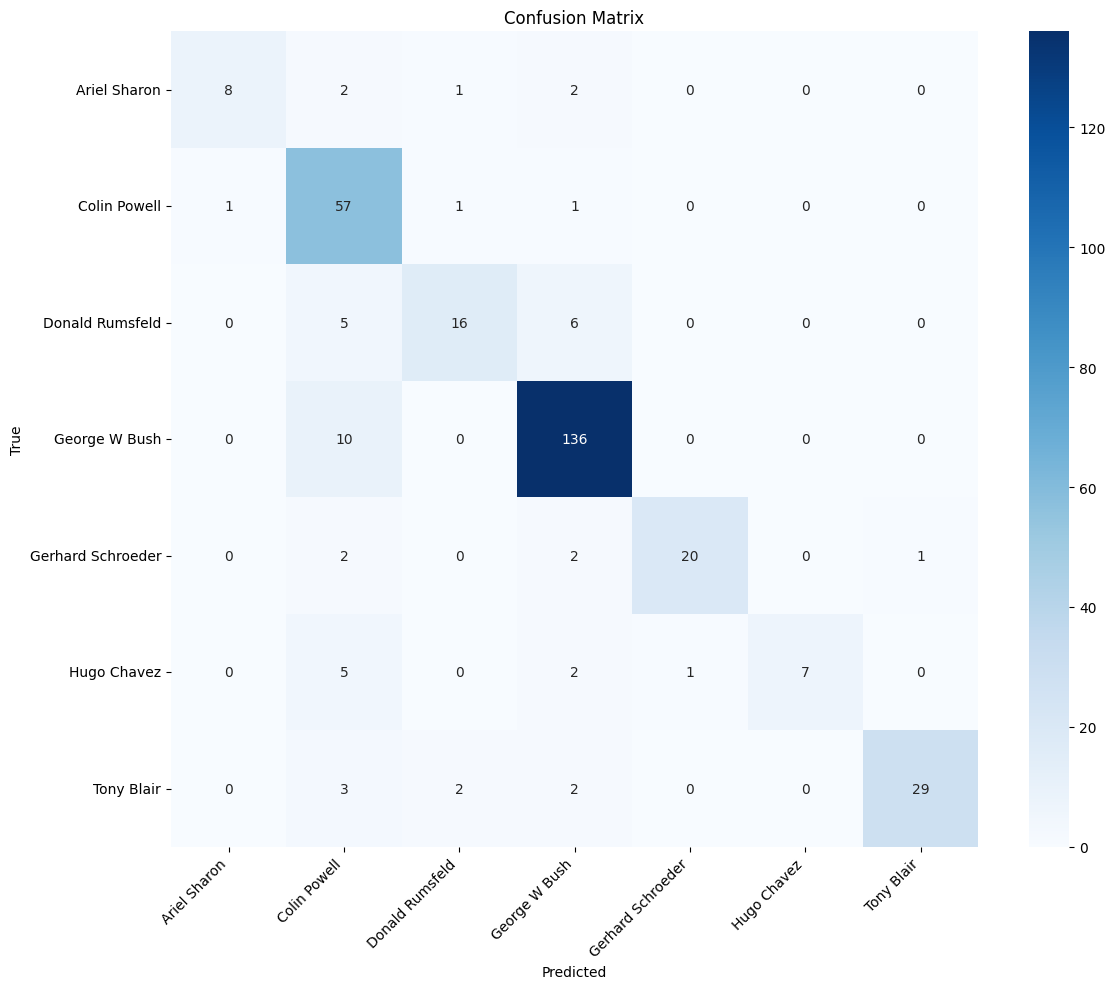

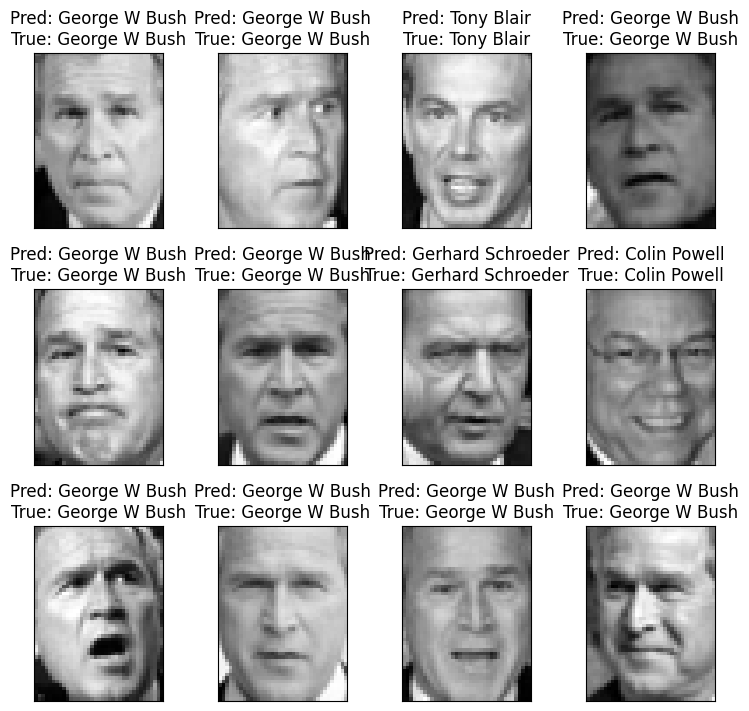

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

# Create output directory
output_dir = "data/output"
os.makedirs(output_dir, exist_ok=True)

# Download and load a subset of the LFW dataset
print("Downloading face dataset (this may take a moment)...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Access data
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Dataset loaded: {len(X)} face images, {n_classes} people")
print(f"People in dataset: {', '.join(target_names)}")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

# Build a face recognition pipeline (PCA + SVM)
n_components = 150
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True)
svc = SVC(kernel='rbf', class_weight='balanced', probability=True)
model = make_pipeline(pca, svc)

# Train the model
print("Training face recognition model...")
model.fit(X_train, y_train)

# Make predictions on the test set
print("Evaluating model...")
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate classification report
report = classification_report(y_test, y_pred, target_names=target_names)
print("Classification Report:")
print(report)

# Save metrics to file
with open(os.path.join(output_dir, "metrics.txt"), "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))

# Visualize some example predictions
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(min(n_row * n_col, len(images))):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.savefig(os.path.join(output_dir, "example_predictions.png"))

# Get prediction titles
prediction_titles = [f"Pred: {target_names[pred]}\nTrue: {target_names[true]}"
                     for pred, true in zip(y_pred, y_test)]

# Plot a subset of the test faces
plot_gallery(X_test, prediction_titles, h=50, w=37)

print(f"Results saved to {output_dir}")